In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('beer-servings.csv')
df

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
3,3,Andorra,245.0,138.0,312.0,12.4,Europe
4,4,Angola,217.0,57.0,45.0,5.9,Africa
...,...,...,...,...,...,...,...
188,188,Venezuela,NaN,100.0,3.0,7.7,South America
189,189,Vietnam,111.0,2.0,1.0,2.0,Asia
190,190,Yemen,6.0,0.0,0.0,0.1,Asia
191,191,Zambia,32.0,19.0,4.0,2.5,Africa


In [3]:
df.describe()

,Unnamed: 0,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,185.000000,185.000000,187.000000,192.000000
mean,96.000000,105.124324,83.221622,50.165775,4.741667
std,55.858452,100.524714,89.142958,80.358868,3.767654
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,20.000000,4.000000,1.000000,1.300000
50%,96.000000,76.000000,60.000000,9.000000,4.250000
75%,144.000000,185.000000,132.000000,60.500000,7.200000
max,192.000000,376.000000,438.000000,370.000000,14.400000


In [4]:
df.dtypes

Unnamed: 0                        int64
country                          object
beer_servings                   float64
spirit_servings                 float64
wine_servings                   float64
total_litres_of_pure_alcohol    float64
continent                        object
dtype: object

In [5]:
df.shape

(193, 7)

In [6]:
df.columns

Index(['Unnamed: 0', 'country', 'beer_servings', 'spirit_servings',
       'wine_servings', 'total_litres_of_pure_alcohol', 'continent'],
      dtype='object')

<Axes: >

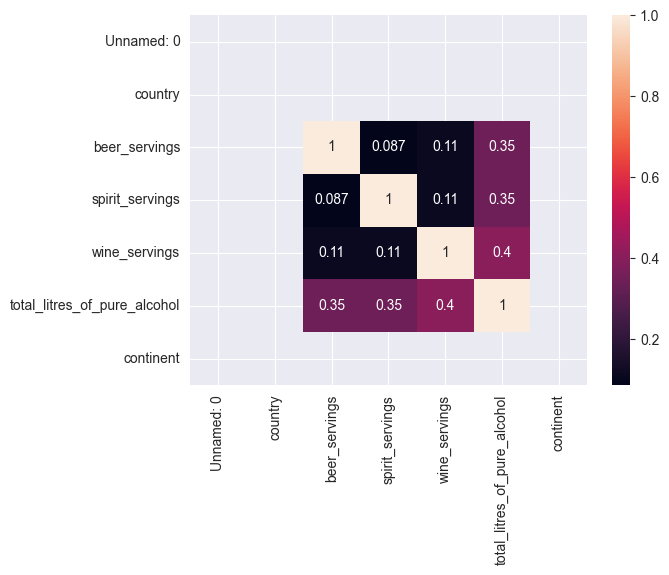

In [7]:
#Visualize missing data (heatmaps, bar plots)
x=df.isnull()
s=x.corr(numeric_only=True)
sns.heatmap(s,annot=True)


<Axes: >

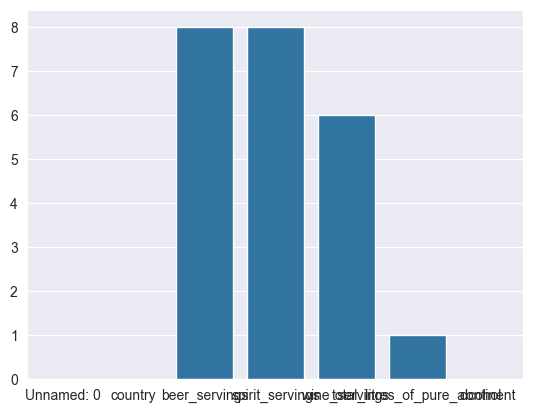

In [8]:
#Visualize missing data (bar plots)
a=df.isnull().sum()
sns.barplot(a)

In [9]:
df.info

<bound method DataFrame.info of      Unnamed: 0      country  beer_servings  spirit_servings  wine_servings  \
0             0  Afghanistan            0.0              0.0            0.0   
1             1      Albania           89.0            132.0           54.0   
2             2      Algeria           25.0              0.0           14.0   
3             3      Andorra          245.0            138.0          312.0   
4             4       Angola          217.0             57.0           45.0   
..          ...          ...            ...              ...            ...   
188         188    Venezuela            NaN            100.0            3.0   
189         189      Vietnam          111.0              2.0            1.0   
190         190        Yemen            6.0              0.0            0.0   
191         191       Zambia           32.0             19.0            4.0   
192         192     Zimbabwe           64.0             18.0            4.0   

     total_litres_o

In [10]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [11]:
df.isnull().sum()

country                         0
beer_servings                   8
spirit_servings                 8
wine_servings                   6
total_litres_of_pure_alcohol    1
continent                       0
dtype: int64

In [12]:
rmv_objct=df.select_dtypes(['float'])
rmv_objct

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,0.0,0.0,0.0,0.0
1,89.0,132.0,54.0,4.9
2,25.0,0.0,14.0,0.7
3,245.0,138.0,312.0,12.4
4,217.0,57.0,45.0,5.9
...,...,...,...,...
188,NaN,100.0,3.0,7.7
189,111.0,2.0,1.0,2.0
190,6.0,0.0,0.0,0.1
191,32.0,19.0,4.0,2.5


array([[<Axes: title={'center': 'beer_servings'}>,
        <Axes: title={'center': 'spirit_servings'}>],
       [<Axes: title={'center': 'wine_servings'}>,
        <Axes: title={'center': 'total_litres_of_pure_alcohol'}>]],
      dtype=object)

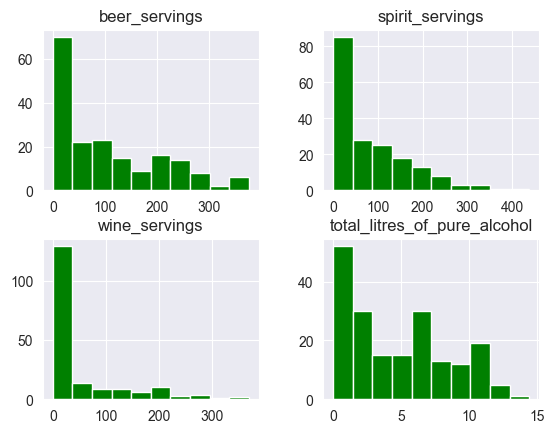

In [13]:
rmv_objct.hist(color="green")

In [14]:
df.columns

Index(['country', 'beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol', 'continent'],
      dtype='object')

In [15]:
df['beer_servings']=df['beer_servings'].fillna(df['beer_servings'].median())
df


,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,Albania,89.0,132.0,54.0,4.9,Europe
2,Algeria,25.0,0.0,14.0,0.7,Africa
3,Andorra,245.0,138.0,312.0,12.4,Europe
4,Angola,217.0,57.0,45.0,5.9,Africa
...,...,...,...,...,...,...
188,Venezuela,76.0,100.0,3.0,7.7,South America
189,Vietnam,111.0,2.0,1.0,2.0,Asia
190,Yemen,6.0,0.0,0.0,0.1,Asia
191,Zambia,32.0,19.0,4.0,2.5,Africa


In [16]:
df.isnull().sum()

country                         0
beer_servings                   0
spirit_servings                 8
wine_servings                   6
total_litres_of_pure_alcohol    1
continent                       0
dtype: int64

In [17]:
for i in ['spirit_servings',
       'wine_servings', 'total_litres_of_pure_alcohol']:
    df[i]=df[i].fillna(df[i].median())
df[i]


0       0.0
1       4.9
2       0.7
3      12.4
4       5.9
       ... 
188     7.7
189     2.0
190     0.1
191     2.5
192     4.7
Name: total_litres_of_pure_alcohol, Length: 193, dtype: float64

In [18]:
df.isnull().sum()

country                         0
beer_servings                   0
spirit_servings                 0
wine_servings                   0
total_litres_of_pure_alcohol    0
continent                       0
dtype: int64

In [19]:
df.columns

Index(['country', 'beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol', 'continent'],
      dtype='object')

Text(0.5, 1.0, 'beer')

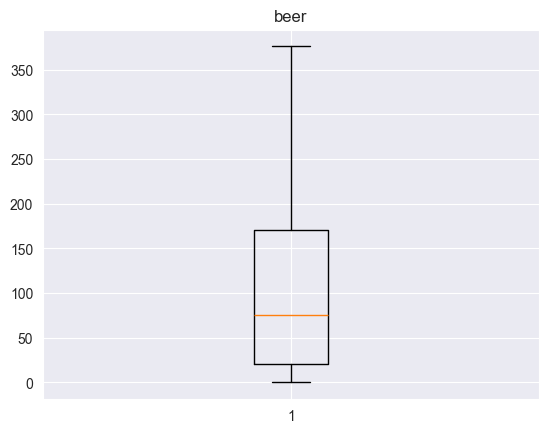

In [20]:
plt.boxplot(df['beer_servings'])
plt.title('beer')

<Axes: >

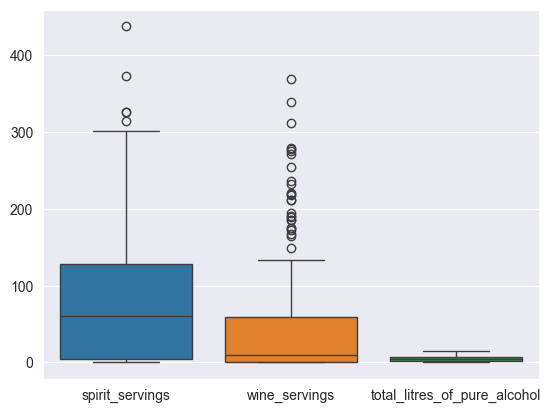

In [21]:
num_colm=['spirit_servings',
       'wine_servings', 'total_litres_of_pure_alcohol']
sns.boxplot(data=df[num_colm])

In [22]:
q1=np.percentile(df['spirit_servings'],25,method="midpoint")
q2=np.percentile(df['spirit_servings'],50,method="midpoint")
q3=np.percentile(df['spirit_servings'],75,method="midpoint")
print(q1)
print(q2)
print(q3)

5.0
60.0
128.0


In [23]:
iqr=q3-q1
iqr

np.float64(123.0)

In [24]:
upper=q3+1.5*iqr
print(upper)
lower=q1-1.5*iqr
print(lower)

312.5
-179.5


In [25]:
outliers=[]
for x in df['spirit_servings']:
    if ((x>upper) or (x<lower)):
        outliers.append(x)
outliers


[373.0, 438.0, 326.0, 326.0, 315.0]

In [26]:
df1=df['spirit_servings']>upper
df1

0      False
1      False
2      False
3      False
4      False
       ...  
188    False
189    False
190    False
191    False
192    False
Name: spirit_servings, Length: 193, dtype: bool

In [27]:
z=df.loc[df1]
z


,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
15,Belarus,142.0,373.0,42.0,14.4,Europe
68,Grenada,199.0,438.0,28.0,11.9,North America
73,Haiti,1.0,326.0,1.0,5.9,North America
141,Russian Federation,247.0,326.0,73.0,11.5,Asia
144,St. Lucia,171.0,315.0,71.0,10.1,North America


In [28]:
df.drop(z.index,inplace=True)
df


,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,Albania,89.0,132.0,54.0,4.9,Europe
2,Algeria,25.0,0.0,14.0,0.7,Africa
3,Andorra,245.0,138.0,312.0,12.4,Europe
4,Angola,217.0,57.0,45.0,5.9,Africa
...,...,...,...,...,...,...
188,Venezuela,76.0,100.0,3.0,7.7,South America
189,Vietnam,111.0,2.0,1.0,2.0,Asia
190,Yemen,6.0,0.0,0.0,0.1,Asia
191,Zambia,32.0,19.0,4.0,2.5,Africa


In [29]:
outliers=[]
for x in df['spirit_servings']:
    if ((x>upper) or (x<lower)):
        outliers.append(x)
outliers

[]

In [30]:
df.reset_index(drop=True,inplace=True)
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,Albania,89.0,132.0,54.0,4.9,Europe
2,Algeria,25.0,0.0,14.0,0.7,Africa
3,Andorra,245.0,138.0,312.0,12.4,Europe
4,Angola,217.0,57.0,45.0,5.9,Africa
...,...,...,...,...,...,...
183,Venezuela,76.0,100.0,3.0,7.7,South America
184,Vietnam,111.0,2.0,1.0,2.0,Asia
185,Yemen,6.0,0.0,0.0,0.1,Asia
186,Zambia,32.0,19.0,4.0,2.5,Africa


In [31]:
#ENCODING
#LABEL ENCODING

In [32]:
df.columns

Index(['country', 'beer_servings', 'spirit_servings', 'wine_servings',
       'total_litres_of_pure_alcohol', 'continent'],
      dtype='object')

In [33]:
df.country.nunique()

188

In [34]:
df.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,Albania,89.0,132.0,54.0,4.9,Europe
2,Algeria,25.0,0.0,14.0,0.7,Africa
3,Andorra,245.0,138.0,312.0,12.4,Europe
4,Angola,217.0,57.0,45.0,5.9,Africa


In [35]:
df.continent.nunique()

6

In [36]:
df.drop('country',axis=1,inplace=True)

In [37]:
from sklearn.preprocessing import LabelEncoder

In [38]:
le=LabelEncoder()

In [39]:
df['continent']=le.fit_transform(df['continent'])

In [40]:
df.head()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0.0,0.0,0.0,0.0,1
1,89.0,132.0,54.0,4.9,2
2,25.0,0.0,14.0,0.7,0
3,245.0,138.0,312.0,12.4,2
4,217.0,57.0,45.0,5.9,0


In [41]:
df

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0.0,0.0,0.0,0.0,1
1,89.0,132.0,54.0,4.9,2
2,25.0,0.0,14.0,0.7,0
3,245.0,138.0,312.0,12.4,2
4,217.0,57.0,45.0,5.9,0
...,...,...,...,...,...
183,76.0,100.0,3.0,7.7,5
184,111.0,2.0,1.0,2.0,1
185,6.0,0.0,0.0,0.1,1
186,32.0,19.0,4.0,2.5,0


In [42]:
#ONE HOT ENCODING


In [43]:
# df.columns

In [44]:
# df.country.nunique()

In [45]:
# df.continent.nunique()

In [46]:
# df.drop('continent',axis=1,inplace=True)

In [47]:
# edf=pd.get_dummies(df)
# edf

In [48]:
# edf.astype(int)

In [49]:
#SCALING
#1 MINMAX SCALING

In [50]:
df

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0.0,0.0,0.0,0.0,1
1,89.0,132.0,54.0,4.9,2
2,25.0,0.0,14.0,0.7,0
3,245.0,138.0,312.0,12.4,2
4,217.0,57.0,45.0,5.9,0
...,...,...,...,...,...
183,76.0,100.0,3.0,7.7,5
184,111.0,2.0,1.0,2.0,1
185,6.0,0.0,0.0,0.1,1
186,32.0,19.0,4.0,2.5,0


In [51]:
x=df.drop(['total_litres_of_pure_alcohol','continent'],axis=1)
x

,beer_servings,spirit_servings,wine_servings
0,0.0,0.0,0.0
1,89.0,132.0,54.0
2,25.0,0.0,14.0
3,245.0,138.0,312.0
4,217.0,57.0,45.0
...,...,...,...
183,76.0,100.0,3.0
184,111.0,2.0,1.0
185,6.0,0.0,0.0
186,32.0,19.0,4.0


In [52]:
y=df[['total_litres_of_pure_alcohol','continent']]
y

,total_litres_of_pure_alcohol,continent
0,0.0,1
1,4.9,2
2,0.7,0
3,12.4,2
4,5.9,0
...,...,...
183,7.7,5
184,2.0,1
185,0.1,1
186,2.5,0


In [53]:
#import
from sklearn.preprocessing import MinMaxScaler

In [54]:
minmax=MinMaxScaler()

In [55]:
x1=minmax.fit_transform(x)
x1

array([[0.        , 0.        , 0.        ],
       [0.23670213, 0.43708609, 0.14594595],
       [0.06648936, 0.        , 0.03783784],
       [0.65159574, 0.45695364, 0.84324324],
       [0.57712766, 0.18874172, 0.12162162],
       [0.2712766 , 0.42384106, 0.12162162],
       [0.20212766, 0.08278146, 0.5972973 ],
       [0.05585106, 0.59271523, 0.02972973],
       [0.69414894, 0.2384106 , 0.57297297],
       [0.74202128, 0.24834437, 0.51621622],
       [0.05585106, 0.15231788, 0.01351351],
       [0.32446809, 0.58278146, 0.13783784],
       [0.11170213, 0.20860927, 0.01891892],
       [0.20212766, 0.1986755 , 0.02432432],
       [0.38031915, 0.57284768, 0.0972973 ],
       [0.78457447, 0.2781457 , 0.57297297],
       [0.69946809, 0.37748344, 0.02162162],
       [0.09042553, 0.01324503, 0.03513514],
       [0.06117021, 0.        , 0.        ],
       [0.44414894, 0.13576159, 0.02162162],
       [0.20212766, 0.57284768, 0.02162162],
       [0.46010638, 0.11589404, 0.09459459],
       [0.

In [56]:
x2=pd.DataFrame(x1,columns=['beer_servings','spirit_servings','wine_servings'])
x2

,beer_servings,spirit_servings,wine_servings
0,0.000000,0.000000,0.000000
1,0.236702,0.437086,0.145946
2,0.066489,0.000000,0.037838
3,0.651596,0.456954,0.843243
4,0.577128,0.188742,0.121622
...,...,...,...
183,0.202128,0.331126,0.008108
184,0.295213,0.006623,0.002703
185,0.015957,0.000000,0.000000
186,0.085106,0.062914,0.010811


In [57]:
# x3=pd.concat([x2[['beer_servings','spirit_servings','wine_servings']],y[['total_litres_of_pure_alcohol','continent']]],axis=1,join='inner')
# x3
x3=pd.concat([x2,y],axis=True)
x3

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0.000000,0.000000,0.000000,0.0,1
1,0.236702,0.437086,0.145946,4.9,2
2,0.066489,0.000000,0.037838,0.7,0
3,0.651596,0.456954,0.843243,12.4,2
4,0.577128,0.188742,0.121622,5.9,0
...,...,...,...,...,...
183,0.202128,0.331126,0.008108,7.7,5
184,0.295213,0.006623,0.002703,2.0,1
185,0.015957,0.000000,0.000000,0.1,1
186,0.085106,0.062914,0.010811,2.5,0


In [58]:
x2.describe()

,beer_servings,spirit_servings,wine_servings
count,188.000000,188.000000,188.000000
mean,0.272974,0.248309,0.132547
std,0.262342,0.250742,0.217145
min,0.000000,0.000000,0.000000
25%,0.055851,0.013245,0.002703
50%,0.202128,0.198675,0.024324
75%,0.445479,0.403974,0.153378
max,1.000000,1.000000,1.000000
